This notebook consists of the feature importance analysis with Scikit-Learn in-built feature importance technique.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns

In [2]:
filepath = "C:/Users/dutts/OneDrive - Johns Hopkins/Documents/ML-Plankton/"
chartpath = "C:/Users/dutts/OneDrive - Johns Hopkins/Documents/ML-Plankton/charts/"
# filepath = "/Users/sdutta/OneDrive - Johns Hopkins/Documents/"
# chartpath = "/Users/sdutta/OneDrive - Johns Hopkins/Documents/plots/charts/"

In [3]:
dk = xr.open_dataset(filepath + "kostadinov/kostadinov_composite_variable_fill.nc")
dc = xr.open_dataset(filepath + "copernicus/2010-2023_cmems_bgc_plankton_variable_fill.nc")
dm = xr.open_dataset(filepath + "modis/2002_2023_modis_variable_fill.nc")

In [4]:
dfk = dk.to_dataframe()
dfk = dfk.astype("float32")
kosta = dfk.dropna()
kosta.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 431112 entries, (-77.5, 1, -178.5) to (83.5, 12, -22.5)
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      431112 non-null  float32
 1   mld      431112 non-null  float32
 2   nh4      431112 non-null  float32
 3   no3      431112 non-null  float32
 4   po4      431112 non-null  float32
 5   rsn      431112 non-null  float32
 6   sst      431112 non-null  float32
 7   sal      431112 non-null  float32
 8   w50      431112 non-null  float32
 9   sil      431112 non-null  float32
 10  logphyc  431112 non-null  float32
 11  phyc     431112 non-null  float32
 12  mcro     431112 non-null  float32
 13  nano     431112 non-null  float32
 14  pico     431112 non-null  float32
 15  logmcro  431112 non-null  float32
 16  lognano  431112 non-null  float32
 17  logpico  431112 non-null  float32
dtypes: float32(18)
memory usage: 31.7 MB


In [5]:
dfc = dc.to_dataframe()
dfc = dfc.astype("float32")
coper = dfc.dropna()
coper.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 430620 entries, (-77.5, 1, -178.5) to (82.5, 12, 81.5)
Data columns (total 20 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      430620 non-null  float32
 1   mld      430620 non-null  float32
 2   nh4      430620 non-null  float32
 3   no3      430620 non-null  float32
 4   po4      430620 non-null  float32
 5   rsn      430620 non-null  float32
 6   sst      430620 non-null  float32
 7   sal      430620 non-null  float32
 8   w50      430620 non-null  float32
 9   sil      430620 non-null  float32
 10  chla     430620 non-null  float32
 11  diat     430620 non-null  float32
 12  mcro     430620 non-null  float32
 13  nano     430620 non-null  float32
 14  pico     430620 non-null  float32
 15  logchla  430620 non-null  float32
 16  logdiat  430620 non-null  float32
 17  logmcro  430620 non-null  float32
 18  lognano  430620 non-null  float32
 19  logpico  430620 non-null  float32
dtyp

In [6]:
dfm = dm.to_dataframe()
dfm = dfm.astype("float32")
modis = dfm.dropna()
modis.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 430380 entries, (-77.5, 1, -178.5) to (83.5, 12, -22.5)
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      430380 non-null  float32
 1   mld      430380 non-null  float32
 2   nh4      430380 non-null  float32
 3   no3      430380 non-null  float32
 4   po4      430380 non-null  float32
 5   rsn      430380 non-null  float32
 6   sst      430380 non-null  float32
 7   sal      430380 non-null  float32
 8   w50      430380 non-null  float32
 9   sil      430380 non-null  float32
 10  chla     430380 non-null  float32
 11  logchla  430380 non-null  float32
 12  mcro     430380 non-null  float32
 13  nano     430380 non-null  float32
 14  pico     430380 non-null  float32
 15  logmcro  430380 non-null  float32
 16  lognano  430380 non-null  float32
 17  logpico  430380 non-null  float32
dtypes: float32(18)
memory usage: 31.6 MB


### Random Forest

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.utils import shuffle
from sklearn.base import BaseEstimator, TransformerMixin

class CustomMinMaxScaler(BaseEstimator, TransformerMixin):
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range

    def fit(self, X, y=None):
        X = self._validate_input(X)
        self.data_min_ = np.min(X, axis=0)
        self.data_max_ = np.max(X, axis=0)
        self.scale_ = (self.feature_range[1] - self.feature_range[0]) / (self.data_max_ - self.data_min_)
        self.min_ = self.feature_range[0] - self.data_min_ * self.scale_
        return self

    def transform(self, X):
        X = self._validate_input(X)
        return X * self.scale_ + self.min_

    def inverse_transform(self, X_scaled):
        X_scaled = self._validate_input(X_scaled)
        return (X_scaled - self.min_) / self.scale_

    def _validate_input(self, X):
        if isinstance(X, pd.DataFrame):
            return X.values
        elif isinstance(X, np.ndarray):
            return X
        else:
            raise ValueError("Input must be a pandas DataFrame or NumPy array.")

In [8]:
scaler = MinMaxScaler(feature_range=(0, 10))

In [9]:
mcolors.TABLEAU_COLORS

{'tab:blue': '#1f77b4',
 'tab:orange': '#ff7f0e',
 'tab:green': '#2ca02c',
 'tab:red': '#d62728',
 'tab:purple': '#9467bd',
 'tab:brown': '#8c564b',
 'tab:pink': '#e377c2',
 'tab:gray': '#7f7f7f',
 'tab:olive': '#bcbd22',
 'tab:cyan': '#17becf'}

In [10]:
blue=mcolors.TABLEAU_COLORS['tab:blue']
orange=mcolors.TABLEAU_COLORS['tab:orange']
green=mcolors.TABLEAU_COLORS['tab:green']
red=mcolors.TABLEAU_COLORS['tab:red']
purple=mcolors.TABLEAU_COLORS['tab:purple']
brown=mcolors.TABLEAU_COLORS['tab:brown']
pink=mcolors.TABLEAU_COLORS['tab:pink']
olive=mcolors.TABLEAU_COLORS['tab:olive']
cyan=mcolors.TABLEAU_COLORS['tab:cyan']
gray=mcolors.TABLEAU_COLORS['tab:gray']

In [11]:
my_colors={'dfe':brown,'mld':olive, 'nh4':purple,'no3':pink, 'po4':cyan, 'rsn':orange,
           'sal':green, 'sst':red, 'sil':blue, 'w50':gray}

In [12]:
n = int(0.7 * kosta.shape[0])

#### Random Forest Kostadinov

In [13]:
kosta = shuffle(kosta)
# kosta = kosta.iloc[:10000]
Xk = kosta.drop(['mcro','nano','pico','phyc','logmcro','lognano','logpico','logphyc'], axis=1)
Xk = Xk.loc[:, ['dfe','mld', 'nh4', 'no3', 'po4', 'rsn', 'sal', 'sst', 'sil', 'w50']]
Xk_train = Xk.iloc[:n,:]
Xk_test = Xk.iloc[n:,:]
Xks_train = scaler.fit_transform(Xk_train)
Xks_train = pd.DataFrame(Xks_train, columns=Xk_train.columns, index=Xk_train.index)
Xks_test = scaler.transform(Xk_test)
Xks_test = pd.DataFrame(Xks_test, columns=Xk_test.columns, index=Xk_test.index) 

ykphyc = kosta['logphyc']
ykmcro = kosta['logmcro']
yknano = kosta['lognano']
ykpico = kosta['logpico']

ykphyc_train = ykphyc[:n]
ykphyc_test  = ykphyc[n:]
ykmcro_train = ykmcro[:n]
ykmcro_test  = ykmcro[n:]
yknano_train = yknano[:n]
yknano_test  = yknano[n:]
ykpico_train = ykpico[:n]
ykpico_test  = ykpico[n:]

In [14]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
kosta_phyc = rf.fit(Xks_train, ykphyc_train)

In [15]:
ykphyc_test_pred = kosta_phyc.predict(Xks_test)
re = np.sqrt(mean_squared_error(ykphyc_test, ykphyc_test_pred))
r2 = r2_score(ykphyc_test,ykphyc_test_pred)
rn = re / ykphyc_test.std()
print("RMSE phyc     : ",re)
print("Norm RMSE phyc: ",rn)
print("R2 Score phyc : ",r2)

RMSE phyc     :  0.11597945614561266
Norm RMSE phyc:  0.3555554151765484
R2 Score phyc :  0.8735794314587829


Reference scores  
RMSE phyc:  0.11565631449027938  
Normalised RMSE phyc:  0.3546560387344827  
R2 Score phyc:  0.874218364787711

In [16]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
kosta_mcro=rf.fit(Xks_train, ykmcro_train)

In [17]:
ykmcro_test_pred = kosta_mcro.predict(Xks_test)
re = np.sqrt(mean_squared_error(ykmcro_test, ykmcro_test_pred))
r2 = r2_score(ykmcro_test,ykmcro_test_pred)
rn = re / ykmcro_test.std()
print("RMSE micro     : ", re)
print("Norm RMSE micro: ",rn)
print("R2 Score micro : ",r2)

RMSE micro     :  0.22426895572954025
Norm RMSE micro:  0.29709031342765474
R2 Score micro :  0.9117387709243238


Reference values  
RMSE:  0.25656060951601983  
Normalised RMSE:  0.2945367249892131  
R2 Score:  0.9132476145598218

In [18]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
kosta_nano=rf.fit(Xks_train, yknano_train)

In [19]:
yknano_test_pred = kosta_nano.predict(Xks_test)
re = np.sqrt(mean_squared_error(yknano_test, yknano_test_pred))
r2 = r2_score(yknano_test,yknano_test_pred)
rn = re / yknano_test.std()
print("RMSE nano     : ", re)
print("Norm RMSE nano: ",rn)
print("R2 Score nano : ",r2)

RMSE nano     :  0.13140823953151615
Norm RMSE nano:  0.27159834811038686
R2 Score nano :  0.9262344438914056


RMSE nano     :  0.12759595566116433  
Norm RMSE nano:  0.2642245026598  
R2 Score nano :  0.9301856745253527

In [20]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
kosta_pico=rf.fit(Xks_train, ykpico_train)

In [21]:
ykpico_test_pred = kosta_pico.predict(Xks_test)
re = np.sqrt(mean_squared_error(ykpico_test, ykpico_test_pred))
r2 = r2_score(ykpico_test,ykpico_test_pred)
rn = re / ykpico_test.std()
print("RMSE pico     : ", re)
print("Norm RMSE pico: ",rn)
print("R2 Score pico : ",r2)

RMSE pico     :  0.07631048882149519
Norm RMSE pico:  0.26958225893675386
R2 Score pico :  0.9273271888924017


RRMSE pico     :  0.0753345793056268  
Norm RMSE pico:  0.2681045799878815  
R2 Score pico :  0.9281200043856538

#### Random Forest Copernicus

In [22]:
coper = shuffle(coper)
Xc = coper.drop(['chla','diat','mcro','nano','pico','logchla','logdiat','logmcro','lognano','logpico'], axis=1)
Xc = Xc.loc[:, ['dfe','mld', 'nh4', 'no3', 'po4', 'rsn', 'sal', 'sst', 'sil', 'w50']]

Xc_train = Xc.iloc[:n,:]
Xc_test  = Xc.iloc[n:,:]
Xcs_train = scaler.fit_transform(Xc_train)
Xcs_train = pd.DataFrame(Xcs_train, columns=Xc_train.columns, index=Xc_train.index)
Xcs_test = scaler.transform(Xc_test)
Xcs_test = pd.DataFrame(Xcs_test, columns=Xc_test.columns, index=Xc_test.index)

ycchla = coper['logchla']
ycmcro = coper['logmcro']
ycnano = coper['lognano']
ycpico = coper['logpico']

ycchla_train = ycchla[:n]
ycchla_test  = ycchla[n:]
ycmcro_train = ycmcro[:n]
ycmcro_test  = ycmcro[n:]
ycnano_train = ycnano[:n]
ycnano_test  = ycnano[n:]
ycpico_train = ycpico[:n]
ycpico_test  = ycpico[n:]

In [23]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
coper_chla=rf.fit(Xcs_train, ycchla_train)

In [24]:
ycchla_test_pred = coper_chla.predict(Xcs_test)
re = np.sqrt(mean_squared_error(ycchla_test, ycchla_test_pred))
r2 = r2_score(ycchla_test,ycchla_test_pred)
rn = re / ycchla_test.std()
print("RMSE chla     : ", re)
print("Norm RMSE chla: ",rn)
print("R2 Score chla : ",r2)

RMSE chla     :  0.1083612302945031
Norm RMSE chla:  0.28636030363278686
R2 Score chla :  0.9179989090904426


RMSE chla     :  0.10686885914520082  
Norm RMSE chla:  0.2826510127890254  
R2 Score chla :  0.92010865618068763

In [25]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
coper_mcro=rf.fit(Xcs_train, ycmcro_train)

In [26]:
ycmcro_test_pred = coper_mcro.predict(Xcs_test)
re = np.sqrt(mean_squared_error(ycmcro_test, ycmcro_test_pred))
r2 = r2_score(ycmcro_test,ycmcro_test_pred)
rn = re / ycmcro_test.std()
print("RMSE micro     : ", re)
print("Norm RMSE micro: ",rn)
print("R2 Score micro : ",r2)

RMSE micro     :  0.1233158721348721
Norm RMSE micro:  0.23184454492557693
R2 Score micro :  0.9462482718440492


RMSE micro     :  0.12193448908775566  
Norm RMSE micro:  0.22952559831484606  
R2 Score micro :  0.947317962257221624

In [27]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
coper_nano=rf.fit(Xcs_train, ycnano_train)

In [28]:
ycnano_test_pred = coper_nano.predict(Xcs_test)
re = np.sqrt(mean_squared_error(ycnano_test, ycnano_test_pred))
r2 = r2_score(ycnano_test,ycnano_test_pred)
rn = re / ycnano_test.std()
print("RMSE nano     : ", re)
print("Norm RMSE nano: ",rn)
print("R2 Score nano : ",r2)

RMSE nano     :  0.10125115869199168
Norm RMSE nano:  0.2865201118150211
R2 Score nano :  0.9179072715046873


RMSE nano     :  0.09965957845363224  
Norm RMSE nano:  0.2832116365027294  
R2 Score nano :  0.919790967317265115

In [29]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
coper_pico=rf.fit(Xcs_train, ycpico_train)

In [30]:
ycpico_test_pred = coper_pico.predict(Xcs_test)
re = np.sqrt(mean_squared_error(ycpico_test, ycpico_test_pred))
r2 = r2_score(ycpico_test,ycpico_test_pred)
rn = re / ycpico_test.std()
print("RMSE pico     : ", re)
print("Norm RMSE pico: ",rn)
print("R2 Score pico : ",r2)

RMSE pico     :  0.10537826069024274
Norm RMSE pico:  0.33757702562330205
R2 Score pico :  0.8860453867198295


RMSE pico     :  0.10410794034379847  
Norm RMSE pico:  0.3342881869579063  
R2 Score pico :  0.888251831894920235

#### Random Forest MODIS

In [31]:
modis = shuffle(modis)
# modis = modis.iloc[:10000]
Xh = modis.drop(['chla','mcro','nano','pico','logchla','logmcro','lognano','logpico'], axis=1)
Xh = Xh.loc[:, ['dfe','mld', 'nh4', 'no3', 'po4', 'rsn', 'sal', 'sst', 'sil', 'w50']]

Xh_train = Xh.iloc[:n,:]
Xhs_train = scaler.fit_transform(Xh_train)
Xhs_train = pd.DataFrame(Xhs_train, columns=Xh_train.columns, index=Xh_train.index)
Xh_test = Xh.iloc[n:,:]
Xhs_test = scaler.transform(Xh_test)
Xhs_test = pd.DataFrame(Xhs_test, columns=Xh_test.columns, index=Xh_test.index)

yhchla = modis['logchla']
yhmcro = modis['logmcro']
yhnano = modis['lognano']
yhpico = modis['logpico']

yhchla_train = yhchla[:n]
yhchla_test  = yhchla[n:]
yhmcro_train = yhmcro[:n]
yhmcro_test  = yhmcro[n:]
yhnano_train = yhnano[:n]
yhnano_test  = yhnano[n:]
yhpico_train = yhpico[:n]
yhpico_test  = yhpico[n:]

In [32]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
modis_chla=rf.fit(Xhs_train, yhchla_train)

In [33]:
yhchla_test_pred = modis_chla.predict(Xhs_test)
re = np.sqrt(mean_squared_error(yhchla_test, yhchla_test_pred))
r2 = r2_score(yhchla_test,yhchla_test_pred)
rn = re / yhchla_test.std()
print("RMSE chla     : ", re)
print("Norm RMSE chla: ",rn)
print("R2 Score chla : ",r2)

RMSE chla     :  0.11971835470826601
Norm RMSE chla:  0.27775976197987684
R2 Score chla :  0.9228509161707893


RMSE chla     :  0.11546389529293932  
Norm RMSE chla:  0.26894533850543734  
R2 Score chla :  0.9276685252078212

In [34]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
modis_mcro=rf.fit(Xhs_train, yhmcro_train)

In [35]:
yhmcro_test_pred = modis_mcro.predict(Xhs_test)
re = np.sqrt(mean_squared_error(yhmcro_test, yhmcro_test_pred))
r2 = r2_score(yhmcro_test,yhmcro_test_pred)
rn = re / yhmcro_test.std()
print("RMSE micro     : ", re)
print("Norm RMSE micro: ",rn)
print("R2 Score micro : ",r2)

RMSE micro     :  0.22810864206005618
Norm RMSE micro:  0.28048082867138424
R2 Score micro :  0.921332995410628


RMSE micro     :  0.21920815171591568  
Norm RMSE micro:  0.2705904905058088  
R2 Score micro :  0.926781127292326

In [36]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
modis_nano=rf.fit(Xhs_train, yhnano_train)

In [37]:
yhnano_test_pred = modis_nano.predict(Xhs_test)
re = np.sqrt(mean_squared_error(yhnano_test, yhnano_test_pred))
r2 = r2_score(yhnano_test,yhnano_test_pred)
rn = re / yhnano_test.std()
print("RMSE nano     : ", re)
print("Norm RMSE nano: ",rn)
print("R2 Score nano : ",r2)

RMSE nano     :  0.12592401614494017
Norm RMSE nano:  0.24495052343128612
R2 Score nano :  0.9399999400190965


RMSE nano     :  0.12207017302838738  
Norm RMSE nano:  0.23801225834896114  
R2 Score nano :  0.9433501471501414

In [38]:
rf = RandomForestRegressor(n_estimators=50, bootstrap=True, max_features="sqrt", min_samples_leaf=5, random_state=101)
modis_pico=rf.fit(Xhs_train, yhpico_train)

In [39]:
yhpico_test_pred = modis_pico.predict(Xhs_test)
re = np.sqrt(mean_squared_error(yhpico_test, yhpico_test_pred))
r2 = r2_score(yhpico_test,yhpico_test_pred)
rn = re / yhpico_test.std()
print("RMSE pico     : ",re)
print("Norm RMSE pico: ",rn)
print("R2 Score pico : ",r2)

RMSE pico     :  0.09036596678318642
Norm RMSE pico:  0.26856698088633996
R2 Score pico :  0.9278736632934823


RMSE pico     :  0.08761586826104123  
Norm RMSE pico:  0.26147695297961415  
R2 Score pico :  0.9316303279659548

### Feature Importance

In [40]:
df_kostaphyc= pd.DataFrame({'Inputs': Xk.columns,'Importances':kosta_phyc.feature_importances_})
df_kostamcro= pd.DataFrame({'Inputs': Xk.columns,'Importances':kosta_mcro.feature_importances_})
df_kostanano= pd.DataFrame({'Inputs': Xk.columns,'Importances':kosta_nano.feature_importances_})
df_kostapico= pd.DataFrame({'Inputs': Xk.columns,'Importances':kosta_pico.feature_importances_})

df_coperchla= pd.DataFrame({'Inputs': Xc.columns,'Importances':coper_chla.feature_importances_})
df_copermcro= pd.DataFrame({'Inputs': Xc.columns,'Importances':coper_mcro.feature_importances_})
df_copernano= pd.DataFrame({'Inputs': Xc.columns,'Importances':coper_nano.feature_importances_})
df_coperpico= pd.DataFrame({'Inputs': Xc.columns,'Importances':coper_pico.feature_importances_})

df_modischla= pd.DataFrame({'Inputs': Xh.columns,'Importances':modis_chla.feature_importances_})
df_modismcro= pd.DataFrame({'Inputs': Xh.columns,'Importances':modis_mcro.feature_importances_})
df_modisnano= pd.DataFrame({'Inputs': Xh.columns,'Importances':modis_nano.feature_importances_})
df_modispico= pd.DataFrame({'Inputs': Xh.columns,'Importances':modis_pico.feature_importances_})

In [41]:
df_coperchla

,Inputs,Importances
0,dfe,0.186986
1,mld,0.067843
2,nh4,0.139540
3,no3,0.077084
4,po4,0.059979
5,rsn,0.159082
6,sal,0.077532
7,sst,0.161485
8,sil,0.034948
9,w50,0.035521


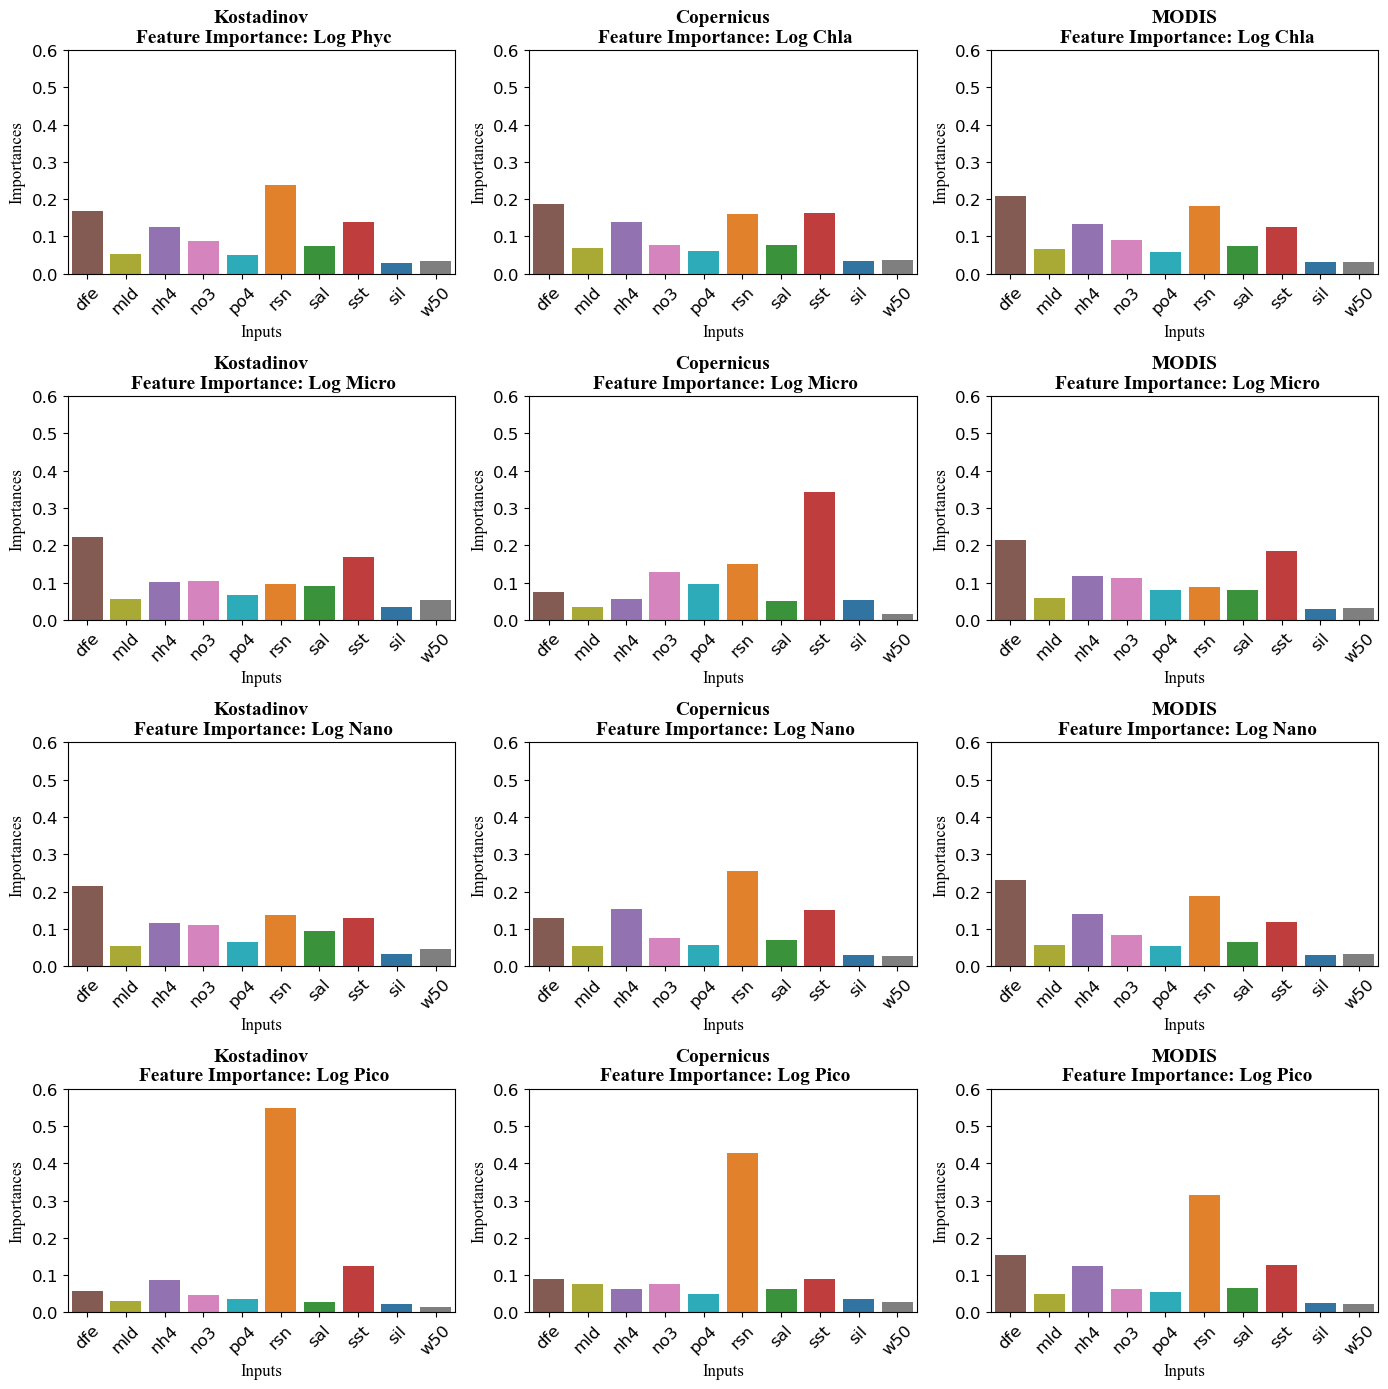

In [42]:
# Define datasets and titles
datasets = [
    {'df': df_kostaphyc, 'x':'Inputs', 'y': 'Importances', 'title': 'Kostadinov\n Feature Importance: Log Phyc'},
    {'df': df_coperchla, 'x':'Inputs', 'y': 'Importances', 'title': 'Copernicus\n Feature Importance: Log Chla'},
    {'df': df_modischla, 'x':'Inputs', 'y': 'Importances', 'title': 'MODIS\n Feature Importance: Log Chla'},
    {'df': df_kostamcro, 'x':'Inputs', 'y': 'Importances', 'title': 'Kostadinov\n Feature Importance: Log Micro'},
    {'df': df_copermcro, 'x':'Inputs', 'y': 'Importances', 'title': 'Copernicus\n Feature Importance: Log Micro'},
    {'df': df_modismcro, 'x':'Inputs', 'y': 'Importances', 'title': 'MODIS\n Feature Importance: Log Micro'},
    {'df': df_kostanano, 'x':'Inputs', 'y': 'Importances', 'title': 'Kostadinov\n Feature Importance: Log Nano'},
    {'df': df_copernano, 'x':'Inputs', 'y': 'Importances', 'title': 'Copernicus\n Feature Importance: Log Nano'},
    {'df': df_modisnano, 'x':'Inputs', 'y': 'Importances', 'title': 'MODIS\n Feature Importance: Log Nano'},
    {'df': df_kostapico, 'x':'Inputs', 'y': 'Importances', 'title': 'Kostadinov\n Feature Importance: Log Pico'},
    {'df': df_coperpico, 'x':'Inputs', 'y': 'Importances', 'title': 'Copernicus\n Feature Importance: Log Pico'},
    {'df': df_modispico, 'x':'Inputs', 'y': 'Importances', 'title': 'MODIS\n Feature Importance: Log Pico'}
]

# Font settings
font = {'family': 'Times New Roman', 'color': 'black', 'fontsize': 14, 'fontweight': 'bold'}
fonttxt = {'family': 'Times New Roman', 'color': 'black', 'fontsize': 12}

# Create subplots (4 rows × 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(14, 14), sharex=False, sharey=False, dpi=100)
axes = axes.flatten()  # Flatten to 1D list for easy iteration

# Plot each dataset
for ax, data in zip(axes, datasets):
    sns.barplot(x=data['x'], y=data['y'], data=data['df'], ax=ax, palette=my_colors, hue=data['x'], legend=False)
    
    ax.set_title(f"{data['title']}", fontdict=font)
    ax.set_ylabel("Importances", fontdict=fonttxt)
    ax.set_ylim([0.0, 0.6])
    ax.set_xlabel("Inputs", fontdict=fonttxt)
    ax.yaxis.set_tick_params(labelsize=12)
    ax.xaxis.set_tick_params(labelsize=12)
    ax.tick_params(axis='x', labelrotation=45)

    
    # Remove legend if present
    if ax.get_legend():
        ax.get_legend().remove()

# Hide any unused axes (in case datasets < total subplots)
for ax in axes[len(datasets):]:
    ax.axis('off')

plt.tight_layout()
fig.savefig(chartpath + "FI_imp_multigroup.jpg",dpi=200,bbox_inches='tight')
plt.show()

### Permutation Importance from Scratch

In [112]:
from sklearn.metrics import root_mean_squared_error

def permutation_importance(model, X, y, metric=root_mean_squared_error, n_repeats=10, random_state=42):
    """
    Compute permutation importance for each feature with multiple shuffles.

    Parameters:
    - model: trained model with .predict() method
    - X: pd.DataFrame, test features
    - y: pd.Series or np.ndarray, true labels
    - metric: scoring function (default: mean_squared_error)
    - squared: bool, if False use RMSE instead of MSE
    - n_repeats: number of times to permute each feature
    - random_state: int or None, controls reproducibility of shuffling

    Returns:
    - pd.DataFrame with mean importance and standard deviation
    """
    rng = np.random.default_rng(random_state)

    # baseline score
    baseline_score = metric(y, model.predict(X))

    results = []
    for feature in X.columns:
        # diffs = []
        pi = []
        for _ in range(n_repeats):
            X_copy = X.copy()
            
            # shuffle feature
            X_copy[feature] = rng.permutation(X_copy[feature].values)
            
            # new score
            perm_score = metric(y, model.predict(X_copy))
            pi.append(perm_score)
            
            # # difference from baseline
            # diffs.append(perm_score - baseline_score)
        
        # results.append({
        #     "feature": feature,
        #     "importance_mean": np.mean(diffs),
        #     "importance_std": np.std(diffs)
        # })

        # If we do not want to take the difference but rather the actual permuted RMSE
        results.append({
            "Inputs": feature,
            "rmse": np.mean(pi),
            "norm_rmse": np.mean(pi) / y.std(),
            "std_dev": np.std(pi)
        })

    df = pd.DataFrame(results)
    # print(df)

    # return pd.DataFrame(results).sort_values(by="rmse", ascending=False).reset_index(drop=True)
    return df

In [113]:
pi_kostaphyc = permutation_importance(kosta_phyc, Xk, ykphyc)
pi_coperchla = permutation_importance(coper_chla, Xc, ycchla)
pi_modischla = permutation_importance(modis_chla, Xh, yhchla)

In [114]:
pi_kostamcro = permutation_importance(kosta_mcro, Xk, ykmcro)
pi_copermcro = permutation_importance(coper_mcro, Xc, ycmcro)
pi_modismcro = permutation_importance(modis_mcro, Xh, yhmcro)

In [115]:
pi_kostanano = permutation_importance(kosta_nano, Xk, yknano)
pi_copernano = permutation_importance(coper_nano, Xc, ycnano)
pi_modisnano = permutation_importance(modis_nano, Xh, yhnano)

In [116]:
pi_kostapico = permutation_importance(kosta_pico, Xk, ykpico)
pi_coperpico = permutation_importance(coper_pico, Xc, ycpico)
pi_modispico = permutation_importance(modis_pico, Xh, yhpico)

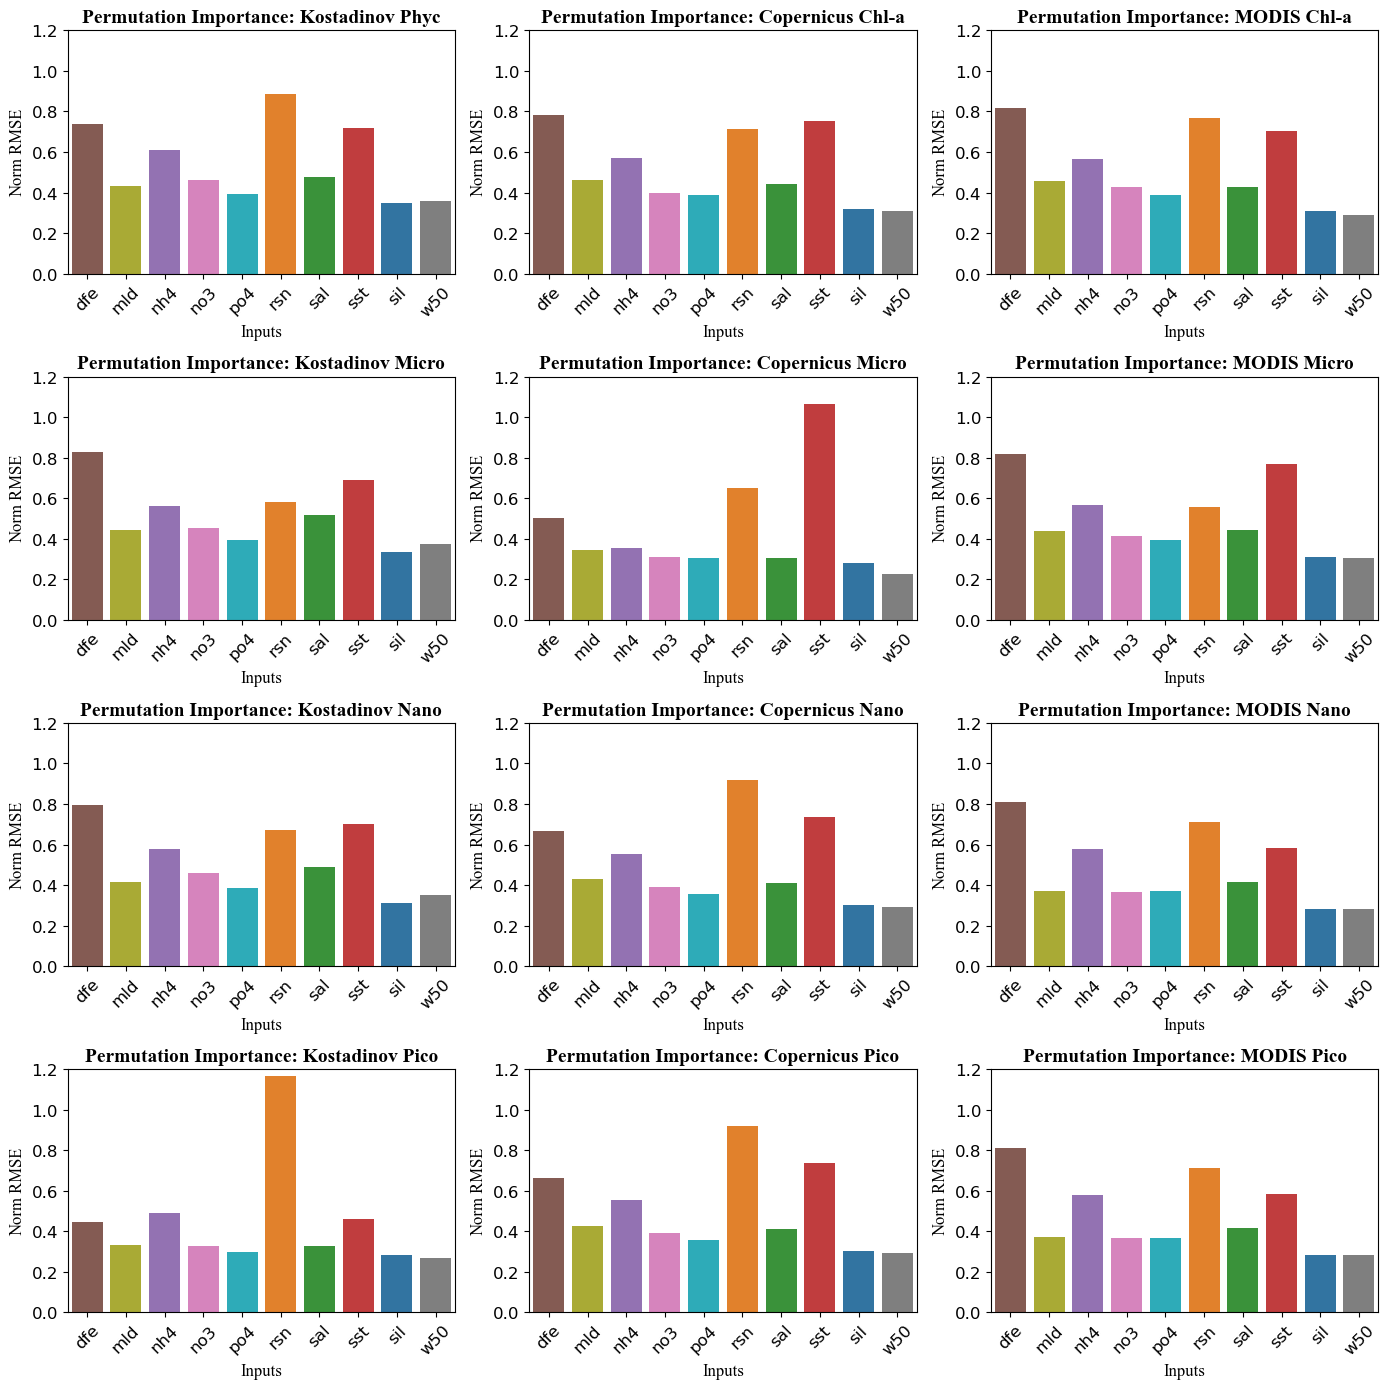

In [117]:
# Define datasets and titles
datasets = [
    {'df': pi_kostaphyc, 'y': 'norm_rmse', 'title': 'Kostadinov Phyc'},
    {'df': pi_coperchla, 'y': 'norm_rmse', 'title': 'Copernicus Chl-a'},
    {'df': pi_modischla, 'y': 'norm_rmse', 'title': 'MODIS Chl-a'},
    {'df': pi_kostamcro, 'y': 'norm_rmse', 'title': 'Kostadinov Micro'},
    {'df': pi_copermcro, 'y': 'norm_rmse', 'title': 'Copernicus Micro'},
    {'df': pi_modismcro, 'y': 'norm_rmse', 'title': 'MODIS Micro'},
    {'df': pi_kostanano, 'y': 'norm_rmse', 'title': 'Kostadinov Nano'},
    {'df': pi_copernano, 'y': 'norm_rmse', 'title': 'Copernicus Nano'},
    {'df': pi_modisnano, 'y': 'norm_rmse', 'title': 'MODIS Nano'},
    {'df': pi_kostapico, 'y': 'norm_rmse', 'title': 'Kostadinov Pico'},
    {'df': pi_copernano, 'y': 'norm_rmse', 'title': 'Copernicus Pico'},
    {'df': pi_modisnano, 'y': 'norm_rmse', 'title': 'MODIS Pico'}
]

# Font settings
font = {'family': 'Times New Roman', 'color': 'black', 'fontsize': 14, 'fontweight': 'bold'}
fonttxt = {'family': 'Times New Roman', 'color': 'black', 'fontsize': 12}

# Create subplots (4 rows × 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(14, 14), sharex=False, sharey=False, dpi=100)
axes = axes.flatten()  # Flatten to 1D list for easy iteration

# Plot each dataset
for ax, data in zip(axes, datasets):
    sns.barplot(x='Inputs', y=data['y'], data=data['df'], ax=ax, palette=my_colors, hue='Inputs', legend=False)
    
    ax.set_title(f"Permutation Importance: {data['title']}", fontdict=font)
    ax.set_ylabel("Norm RMSE", fontdict=fonttxt)
    ax.set_ylim([0.0, 1.2])
    ax.set_xlabel("Inputs", fontdict=fonttxt)
    ax.yaxis.set_tick_params(labelsize=12)
    ax.xaxis.set_tick_params(labelsize=12)
    ax.tick_params(axis='x', labelrotation=45)

    
    # Remove legend if present
    if ax.get_legend():
        ax.get_legend().remove()

# Hide any unused axes (in case datasets < total subplots)
for ax in axes[len(datasets):]:
    ax.axis('off')

plt.tight_layout()
fig.savefig(chartpath + "pi_imp_multigroup_scratch.jpg",dpi=200,bbox_inches='tight')
plt.show()

### Variable Importance

In [118]:
def compute_ale_multi(X, model, features, bins=20):
    """
    Compute Accumulated Local Effects (ALE) for multiple features.
    
    Parameters:
    - X: pd.DataFrame, input data
    - model: trained model with .predict() method
    - features: list of str, names of the features to compute ALE for
    - bins: int, number of bins to divide each feature range
    
    Returns:
    - ale_df: pd.DataFrame with columns ['feature', 'bin_center', 'ALE']
    """
    all_ales = []

    for feature in features:
        x_feature = X[feature].values
        quantiles = np.quantile(x_feature, np.linspace(0, 1, bins + 1))

        ale_values = []
        bin_centers = []

        for i in range(1, len(quantiles)):
            lower, upper = quantiles[i-1], quantiles[i]
            mask = (x_feature >= lower) & (x_feature < upper)
            X_bin = X[mask].copy()

            if len(X_bin) == 0:
                ale_values.append(0)
                bin_centers.append((lower + upper) / 2)
                continue

            # Predict with feature = upper
            X_bin[feature] = upper
            preds_upper = model.predict(X_bin)

            # Predict with feature = lower
            X_bin[feature] = lower
            preds_lower = model.predict(X_bin)

            # Average difference
            delta = np.mean(preds_upper - preds_lower)

            ale_values.append(delta)
            bin_centers.append((lower + upper) / 2)

        # Accumulate effects
        ale_cum = np.cumsum(ale_values)

        # Center ALE to have mean zero
        ale_cum -= np.mean(ale_cum)

        # Collect results
        df = pd.DataFrame({
            "feature": feature,
            "bin_center": bin_centers,
            "ALE": ale_cum
        })
        all_ales.append(df)

    # Combine into single DataFrame
    ale_df = pd.concat(all_ales, ignore_index=True)
    return ale_df

In [119]:
features = Xk.columns.to_list()

In [120]:
exp_kostaphyc = compute_ale_multi(Xk, kosta_phyc, features, bins=20)
exp_coperchla = compute_ale_multi(Xc, coper_chla, features, bins=20)
exp_modischla = compute_ale_multi(Xh, modis_chla, features, bins=20)

In [121]:
exp_kostaphyc

,feature,bin_center,ALE
0,dfe,7.438728e-08,-0.270583
1,dfe,1.150132e-07,-0.211678
2,dfe,1.452120e-07,-0.198045
3,dfe,1.716450e-07,-0.152132
4,dfe,1.960377e-07,-0.098119
...,...,...,...
195,w50,1.252520e-06,0.004790
196,w50,1.597807e-06,0.002637
197,w50,2.113793e-06,0.002246
198,w50,3.234453e-06,0.005999


In [122]:
exp_kostaphyc[exp_kostaphyc['feature']=='dfe']['ALE'].std()

np.float64(0.13223904742705467)

In [123]:
features

['dfe', 'mld', 'nh4', 'no3', 'po4', 'rsn', 'sal', 'sst', 'sil', 'w50']

In [124]:
kostaphyc = {}
coperchla = {}
modischla = {}
for f in features:
    kostaphyc[f] =exp_kostaphyc[exp_kostaphyc['feature']== f]['ALE'].std()
    coperchla[f] =exp_coperchla[exp_coperchla['feature']== f]['ALE'].std()
    modischla[f] =exp_modischla[exp_modischla['feature']== f]['ALE'].std()

In [125]:
data_phyc = {
    'kostaphyc': kostaphyc,
    'coperchla': coperchla,
    'modischla': modischla
}

In [126]:
data_phyc

{'kostaphyc': {'dfe': np.float64(0.13223904742705467),
  'mld': np.float64(0.02645600275292867),
  'nh4': np.float64(0.08470344886226282),
  'no3': np.float64(0.024642029831763012),
  'po4': np.float64(0.015862456404682583),
  'rsn': np.float64(0.14815663220048877),
  'sal': np.float64(0.03484761670088628),
  'sst': np.float64(0.07118238929657618),
  'sil': np.float64(0.015679564149737493),
  'w50': np.float64(0.011342083851383238)},
 'coperchla': {'dfe': np.float64(0.17181426613400608),
  'mld': np.float64(0.03623297904447079),
  'nh4': np.float64(0.09525938839704552),
  'no3': np.float64(0.022488752772995),
  'po4': np.float64(0.01960396944495069),
  'rsn': np.float64(0.13109828647508168),
  'sal': np.float64(0.04087554303950357),
  'sst': np.float64(0.12549388075464585),
  'sil': np.float64(0.031753640959669545),
  'w50': np.float64(0.013866571196233317)},
 'modischla': {'dfe': np.float64(0.21893697305383264),
  'mld': np.float64(0.04262531695533319),
  'nh4': np.float64(0.117508972

In [127]:
phyc = pd.DataFrame(data_phyc)

In [128]:
# phyc = phyc.iloc[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]
# phyc = phyc.rename(index={'logdfe':'dfe'})
phyc

,kostaphyc,coperchla,modischla
dfe,0.132239,0.171814,0.218937
mld,0.026456,0.036233,0.042625
nh4,0.084703,0.095259,0.117509
no3,0.024642,0.022489,0.036554
po4,0.015862,0.019604,0.028044
rsn,0.148157,0.131098,0.191892
sal,0.034848,0.040876,0.045039
sst,0.071182,0.125494,0.126838
sil,0.015680,0.031754,0.049849
w50,0.011342,0.013867,0.012087


In [129]:
exp_kostamcro = compute_ale_multi(Xk, kosta_mcro, features, bins=20)
exp_copermcro = compute_ale_multi(Xc, coper_mcro, features, bins=20)
exp_modismcro = compute_ale_multi(Xh, modis_mcro, features, bins=20)

In [130]:
exp_kostamcro

,feature,bin_center,ALE
0,dfe,7.438728e-08,-0.748993
1,dfe,1.150132e-07,-0.628004
2,dfe,1.452120e-07,-0.590680
3,dfe,1.716450e-07,-0.478811
4,dfe,1.960377e-07,-0.348619
...,...,...,...
195,w50,1.252520e-06,0.028613
196,w50,1.597807e-06,0.020940
197,w50,2.113793e-06,0.002979
198,w50,3.234453e-06,0.003780


In [131]:
kostamcro = {}
copermcro = {}
modismcro = {}
for f in features:
    kostamcro[f] =exp_kostamcro[exp_kostamcro['feature']==f]['ALE'].std()
    copermcro[f] =exp_copermcro[exp_copermcro['feature']==f]['ALE'].std()
    modismcro[f] =exp_modismcro[exp_modismcro['feature']==f]['ALE'].std()

In [132]:
data_mcro = {
    'kostamcro': kostamcro,
    'copermcro': copermcro,
    'modismcro': modismcro
}

In [133]:
mcro = pd.DataFrame(data_mcro)
# mcro = mcro.iloc[[9, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
# mcro = mcro.rename(index={'logdfe':'dfe'})
mcro

,kostamcro,copermcro,modismcro
dfe,0.412013,0.154200,0.424578
mld,0.083461,0.033775,0.083956
nh4,0.179414,0.091784,0.222240
no3,0.083059,0.027568,0.058709
po4,0.037338,0.026431,0.050210
rsn,0.150213,0.188161,0.128396
sal,0.099678,0.031054,0.092573
sst,0.166681,0.339906,0.258337
sil,0.070722,0.071481,0.062739
w50,0.031741,0.012881,0.025170


In [134]:
exp_kostanano = compute_ale_multi(Xk, kosta_nano, features, bins=20)
exp_copernano = compute_ale_multi(Xc, coper_nano, features, bins=20)
exp_modisnano = compute_ale_multi(Xh, modis_nano, features, bins=20)

In [135]:
kostanano = {}
copernano = {}
modisnano = {}
for f in features:
    kostanano[f] =exp_kostanano[exp_kostanano['feature']==f]['ALE'].std()
    copernano[f] =exp_copernano[exp_copernano['feature']==f]['ALE'].std()
    modisnano[f] =exp_modisnano[exp_modisnano['feature']==f]['ALE'].std()

In [136]:
data_nano = {
    'kostanano': kostanano,
    'copernano': copernano,
    'modisnano': modisnano
}

In [137]:
nano = pd.DataFrame(data_nano)
# nano = nano.iloc[[9, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
# nano = nano.rename(index={'logdfe':'dfe'})
nano

,kostanano,copernano,modisnano
dfe,0.253124,0.135644,0.239248
mld,0.047608,0.035118,0.031738
nh4,0.119472,0.099711,0.130213
no3,0.046022,0.024467,0.031952
po4,0.023306,0.022078,0.037500
rsn,0.164090,0.204588,0.217420
sal,0.064446,0.034904,0.065988
sst,0.109806,0.120483,0.124751
sil,0.047828,0.031866,0.031157
w50,0.017844,0.010738,0.010773


In [138]:
exp_kostapico = compute_ale_multi(Xk, kosta_pico, features, bins=20)
exp_coperpico = compute_ale_multi(Xc, coper_pico, features, bins=20)
exp_modispico = compute_ale_multi(Xh, modis_pico, features, bins=20)

In [139]:
kostapico = {}
coperpico = {}
modispico = {}
for f in features:
    kostapico[f] =exp_kostapico[exp_kostapico['feature']==f]['ALE'].std()
    coperpico[f] =exp_coperpico[exp_coperpico['feature']==f]['ALE'].std()
    modispico[f] =exp_modispico[exp_modispico['feature']==f]['ALE'].std()

In [140]:
data_pico = {
    'kostapico': kostapico,
    'coperpico': coperpico,
    'modispico': modispico
}

In [141]:
pico = pd.DataFrame(data_pico)
# pico = pico.iloc[[9, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
# pico = pico.rename(index={'logdfe':'dfe'})
pico

,kostapico,coperpico,modispico
dfe,0.070175,0.097698,0.149791
mld,0.012110,0.031580,0.030043
nh4,0.041428,0.052837,0.083109
no3,0.011972,0.021629,0.024586
po4,0.012377,0.011917,0.015612
rsn,0.242847,0.223375,0.233904
sal,0.015736,0.020345,0.030086
sst,0.037556,0.039660,0.088858
sil,0.026865,0.052074,0.032642
w50,0.003777,0.007155,0.006480


In [142]:
blue=mcolors.TABLEAU_COLORS['tab:blue']
orange=mcolors.TABLEAU_COLORS['tab:orange']
green=mcolors.TABLEAU_COLORS['tab:green']
red=mcolors.TABLEAU_COLORS['tab:red']
purple=mcolors.TABLEAU_COLORS['tab:purple']
brown=mcolors.TABLEAU_COLORS['tab:brown']
pink=mcolors.TABLEAU_COLORS['tab:pink']
olive=mcolors.TABLEAU_COLORS['tab:olive']
cyan=mcolors.TABLEAU_COLORS['tab:cyan']
gray=mcolors.TABLEAU_COLORS['tab:gray']

In [143]:
my_colors={'dfe':brown,'rsn':orange,'sst':red,'nh4':purple,'no3':pink,'mld':olive,
           'sal':green,'po4':cyan,'w50':gray,'sil':blue}

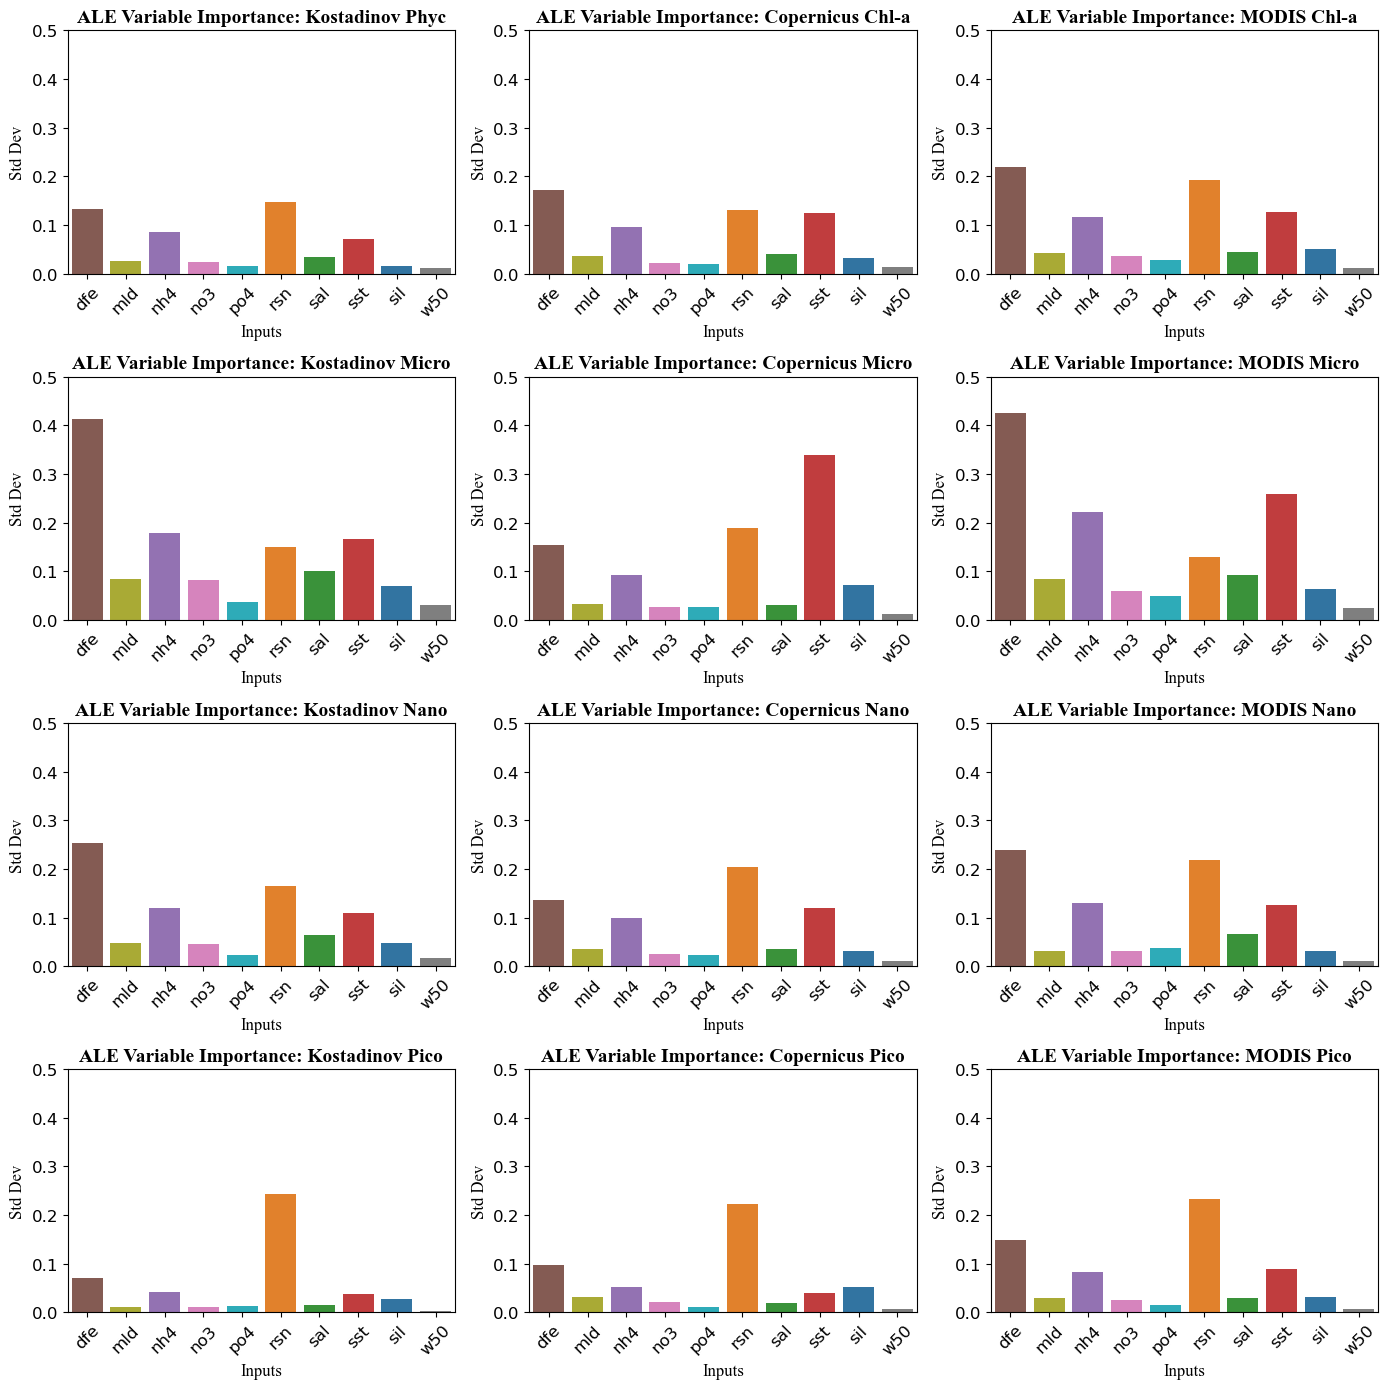

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reset index to get 'Inputs' as a column
phyc_reset = phyc.reset_index().rename(columns={'index': 'Inputs'})
mcro_reset = mcro.reset_index().rename(columns={'index': 'Inputs'})
nano_reset = nano.reset_index().rename(columns={'index': 'Inputs'})
pico_reset = pico.reset_index().rename(columns={'index': 'Inputs'})

# Define datasets and titles
datasets = [
    {'df': phyc_reset, 'y': 'kostaphyc', 'title': 'Kostadinov Phyc'},
    {'df': phyc_reset, 'y': 'coperchla', 'title': 'Copernicus Chl-a'},
    {'df': phyc_reset, 'y': 'modischla', 'title': 'MODIS Chl-a'},
    {'df': mcro_reset, 'y': 'kostamcro', 'title': 'Kostadinov Micro'},
    {'df': mcro_reset, 'y': 'copermcro', 'title': 'Copernicus Micro'},
    {'df': mcro_reset, 'y': 'modismcro', 'title': 'MODIS Micro'},
    {'df': nano_reset, 'y': 'kostanano', 'title': 'Kostadinov Nano'},
    {'df': nano_reset, 'y': 'copernano', 'title': 'Copernicus Nano'},
    {'df': nano_reset, 'y': 'modisnano', 'title': 'MODIS Nano'},
    {'df': pico_reset, 'y': 'kostapico', 'title': 'Kostadinov Pico'},
    {'df': pico_reset, 'y': 'coperpico', 'title': 'Copernicus Pico'},
    {'df': pico_reset, 'y': 'modispico', 'title': 'MODIS Pico'}
]

# Font settings
font = {'family': 'Times New Roman', 'color': 'black', 'fontsize': 14, 'fontweight': 'bold'}
fonttxt = {'family': 'Times New Roman', 'color': 'black', 'fontsize': 12}

# Create subplots (4 rows × 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(14, 14), sharex=False, sharey=False, dpi=100)
axes = axes.flatten()  # Flatten to 1D list for easy iteration

# Plot each dataset
for ax, data in zip(axes, datasets):
    sns.barplot(x='Inputs', y=data['y'], data=data['df'], ax=ax, palette=my_colors, hue='Inputs', legend=False)
    
    ax.set_title(f"ALE Variable Importance: {data['title']}", fontdict=font)
    ax.set_ylabel("Std Dev", fontdict=fonttxt)
    ax.set_ylim([0.0, 0.5])
    ax.set_xlabel("Inputs", fontdict=fonttxt)
    ax.yaxis.set_tick_params(labelsize=12)
    ax.xaxis.set_tick_params(labelsize=12)
    ax.tick_params(axis='x', labelrotation=45)

    
    # Remove legend if present
    if ax.get_legend():
        ax.get_legend().remove()

# Hide any unused axes (in case datasets < total subplots)
for ax in axes[len(datasets):]:
    ax.axis('off')

plt.tight_layout()
fig.savefig(chartpath + "ale_VI_multigroup_scratch.jpg",dpi=200,bbox_inches='tight')
plt.show()